In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


#Load the dataset

In [90]:
df = pd.read_csv('./data explorer/Customer-Churn-Records.csv')
print(df.head())

   RowNumber  CustomerId   Surname  CreditScore Geography  Gender  Age  \
0          1    15634602  Hargrave          619    France  Female   42   
1          2    15647311      Hill          608     Spain  Female   41   
2          3    15619304      Onio          502    France  Female   42   
3          4    15701354      Boni          699    France  Female   39   
4          5    15737888  Mitchell          850     Spain  Female   43   

   Tenure    Balance  NumOfProducts  HasCrCard  IsActiveMember  \
0       2       0.00              1          1               1   
1       1   83807.86              1          0               1   
2       8  159660.80              3          1               0   
3       1       0.00              2          0               0   
4       2  125510.82              1          1               1   

   EstimatedSalary  Exited  Complain  Satisfaction Score Card Type  \
0        101348.88       1         1                   2   DIAMOND   
1        112542.58

In [91]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RowNumber           10000 non-null  int64  
 1   CustomerId          10000 non-null  int64  
 2   Surname             10000 non-null  object 
 3   CreditScore         10000 non-null  int64  
 4   Geography           10000 non-null  object 
 5   Gender              10000 non-null  object 
 6   Age                 10000 non-null  int64  
 7   Tenure              10000 non-null  int64  
 8   Balance             10000 non-null  float64
 9   NumOfProducts       10000 non-null  int64  
 10  HasCrCard           10000 non-null  int64  
 11  IsActiveMember      10000 non-null  int64  
 12  EstimatedSalary     10000 non-null  float64
 13  Exited              10000 non-null  int64  
 14  Complain            10000 non-null  int64  
 15  Satisfaction Score  10000 non-null  int64  
 16  Card 

# Insight from the dataset exploration

data size 10000,
total column 18 (include the target variable)

Non important feature are
RowNumber, CustomerId , Surname

## important Feature Overview
* Numerical feature
    CreditScore, Age, Tenure, Balance, EstimatedSalary, Point Earned 
* Categorical feature
    HasCrCard, IsActiveMember, Exited, CardType, Geography, NumOfProduct, Gender, Satisfaction Score

# Dropout non meaningful feature 
RowNumber, CustomerId , Surname

In [92]:
df.drop(['RowNumber', 'CustomerId', 'Surname'], axis=1, inplace=True)

# Handle missing value

In [93]:
dfTotalNullValues =df.isnull().sum().sum()
if(dfTotalNullValues):
    print("Missing values in the dataset", dfTotalNullValues)
else:
    print("No missing values in the dataset")

df.info()

No missing values in the dataset
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   CreditScore         10000 non-null  int64  
 1   Geography           10000 non-null  object 
 2   Gender              10000 non-null  object 
 3   Age                 10000 non-null  int64  
 4   Tenure              10000 non-null  int64  
 5   Balance             10000 non-null  float64
 6   NumOfProducts       10000 non-null  int64  
 7   HasCrCard           10000 non-null  int64  
 8   IsActiveMember      10000 non-null  int64  
 9   EstimatedSalary     10000 non-null  float64
 10  Exited              10000 non-null  int64  
 11  Complain            10000 non-null  int64  
 12  Satisfaction Score  10000 non-null  int64  
 13  Card Type           10000 non-null  object 
 14  Point Earned        10000 non-null  int64  
dtypes: float64(2), int64(

# Feature fiter

In [94]:
df.columns = (df.columns
      .str.strip()
      .str.replace(' ', ''))
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Complain,SatisfactionScore,CardType,PointEarned
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1,1,2,DIAMOND,464
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,1,3,DIAMOND,456
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,1,3,DIAMOND,377
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0,0,5,GOLD,350
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,0,5,GOLD,425


In [95]:
stats = df.describe().T.style \
        .set_table_styles([{
            'selector': 'th',
            'props': [('font-size', '14px'), ('text-align', 'center')]
        }]) \
        .background_gradient(cmap='Blues') \
        .set_caption("📊 Dataset Summary Statistics")

stats


,count,mean,std,min,25%,50%,75%,max
CreditScore,10000.000000,650.528800,96.653299,350.000000,584.000000,652.000000,718.000000,850.000000
Age,10000.000000,38.921800,10.487806,18.000000,32.000000,37.000000,44.000000,92.000000
Tenure,10000.000000,5.012800,2.892174,0.000000,3.000000,5.000000,7.000000,10.000000
Balance,10000.000000,76485.889288,62397.405202,0.000000,0.000000,97198.540000,127644.240000,250898.090000
NumOfProducts,10000.000000,1.530200,0.581654,1.000000,1.000000,1.000000,2.000000,4.000000
HasCrCard,10000.000000,0.705500,0.455840,0.000000,0.000000,1.000000,1.000000,1.000000
IsActiveMember,10000.000000,0.515100,0.499797,0.000000,0.000000,1.000000,1.000000,1.000000
EstimatedSalary,10000.000000,100090.239881,57510.492818,11.580000,51002.110000,100193.915000,149388.247500,199992.480000
Exited,10000.000000,0.203800,0.402842,0.000000,0.000000,0.000000,0.000000,1.000000
Complain,10000.000000,0.204400,0.403283,0.000000,0.000000,0.000000,0.000000,1.000000


# Descriptive Insights from Dataset Statistics
* CreditScore
    mean : 650
    Standard deviation : 96.65
    min - max : 350 to 850 (high dispersion)

In [96]:
categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Categorical Columns:", categorical_columns)
print("Numerical Columns:", numerical_columns)

Categorical Columns: Index(['Geography', 'Gender', 'CardType'], dtype='object')
Numerical Columns: Index(['CreditScore', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Complain',
       'SatisfactionScore', 'PointEarned'],
      dtype='object')


Now we convert the data into smaller unit so it will take small memory

In [97]:
def convert_obj_to_cat(df,categorical_columns=categorical_columns):
    for col in categorical_columns:
        if col in df.columns:
            df[col] = df[col].astype('category')
        else:
            pass
    
def convert_num_to_smallest(df,numerical_columns=numerical_columns):
    for col in numerical_columns:
         if df[col].dtype == 'int64':
            df[col] = df[col].astype('int8')
         elif df[col].dtype == 'float64':
            df[col] = df[col].astype('float32')
         else:
            pass

convert_obj_to_cat(df,categorical_columns)
convert_num_to_smallest(df,numerical_columns)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   CreditScore        10000 non-null  int8    
 1   Geography          10000 non-null  category
 2   Gender             10000 non-null  category
 3   Age                10000 non-null  int8    
 4   Tenure             10000 non-null  int8    
 5   Balance            10000 non-null  float32 
 6   NumOfProducts      10000 non-null  int8    
 7   HasCrCard          10000 non-null  int8    
 8   IsActiveMember     10000 non-null  int8    
 9   EstimatedSalary    10000 non-null  float32 
 10  Exited             10000 non-null  int8    
 11  Complain           10000 non-null  int8    
 12  SatisfactionScore  10000 non-null  int8    
 13  CardType           10000 non-null  category
 14  PointEarned        10000 non-null  int8    
dtypes: category(3), float32(2), int8(10)
memory usage: 205

In [98]:
numerical_categories = ["NumOfProducts","HasCrCard","IsActiveMember","Complain","SatisfactionScore"]
for col in numerical_categories:
    df[col] = df[col].astype('category')

df.describe(include="category").T.style

,count,unique,top,freq
Geography,10000,3,France,5014
Gender,10000,2,Male,5457
NumOfProducts,10000,4,1,5084
HasCrCard,10000,2,1,7055
IsActiveMember,10000,2,1,5151
Complain,10000,2,0,7956
SatisfactionScore,10000,5,3,2042
CardType,10000,4,DIAMOND,2507


# Checking Duplicate value

In [99]:
df.duplicated().any()


False

no duplicate found

# Checking Outlier Value

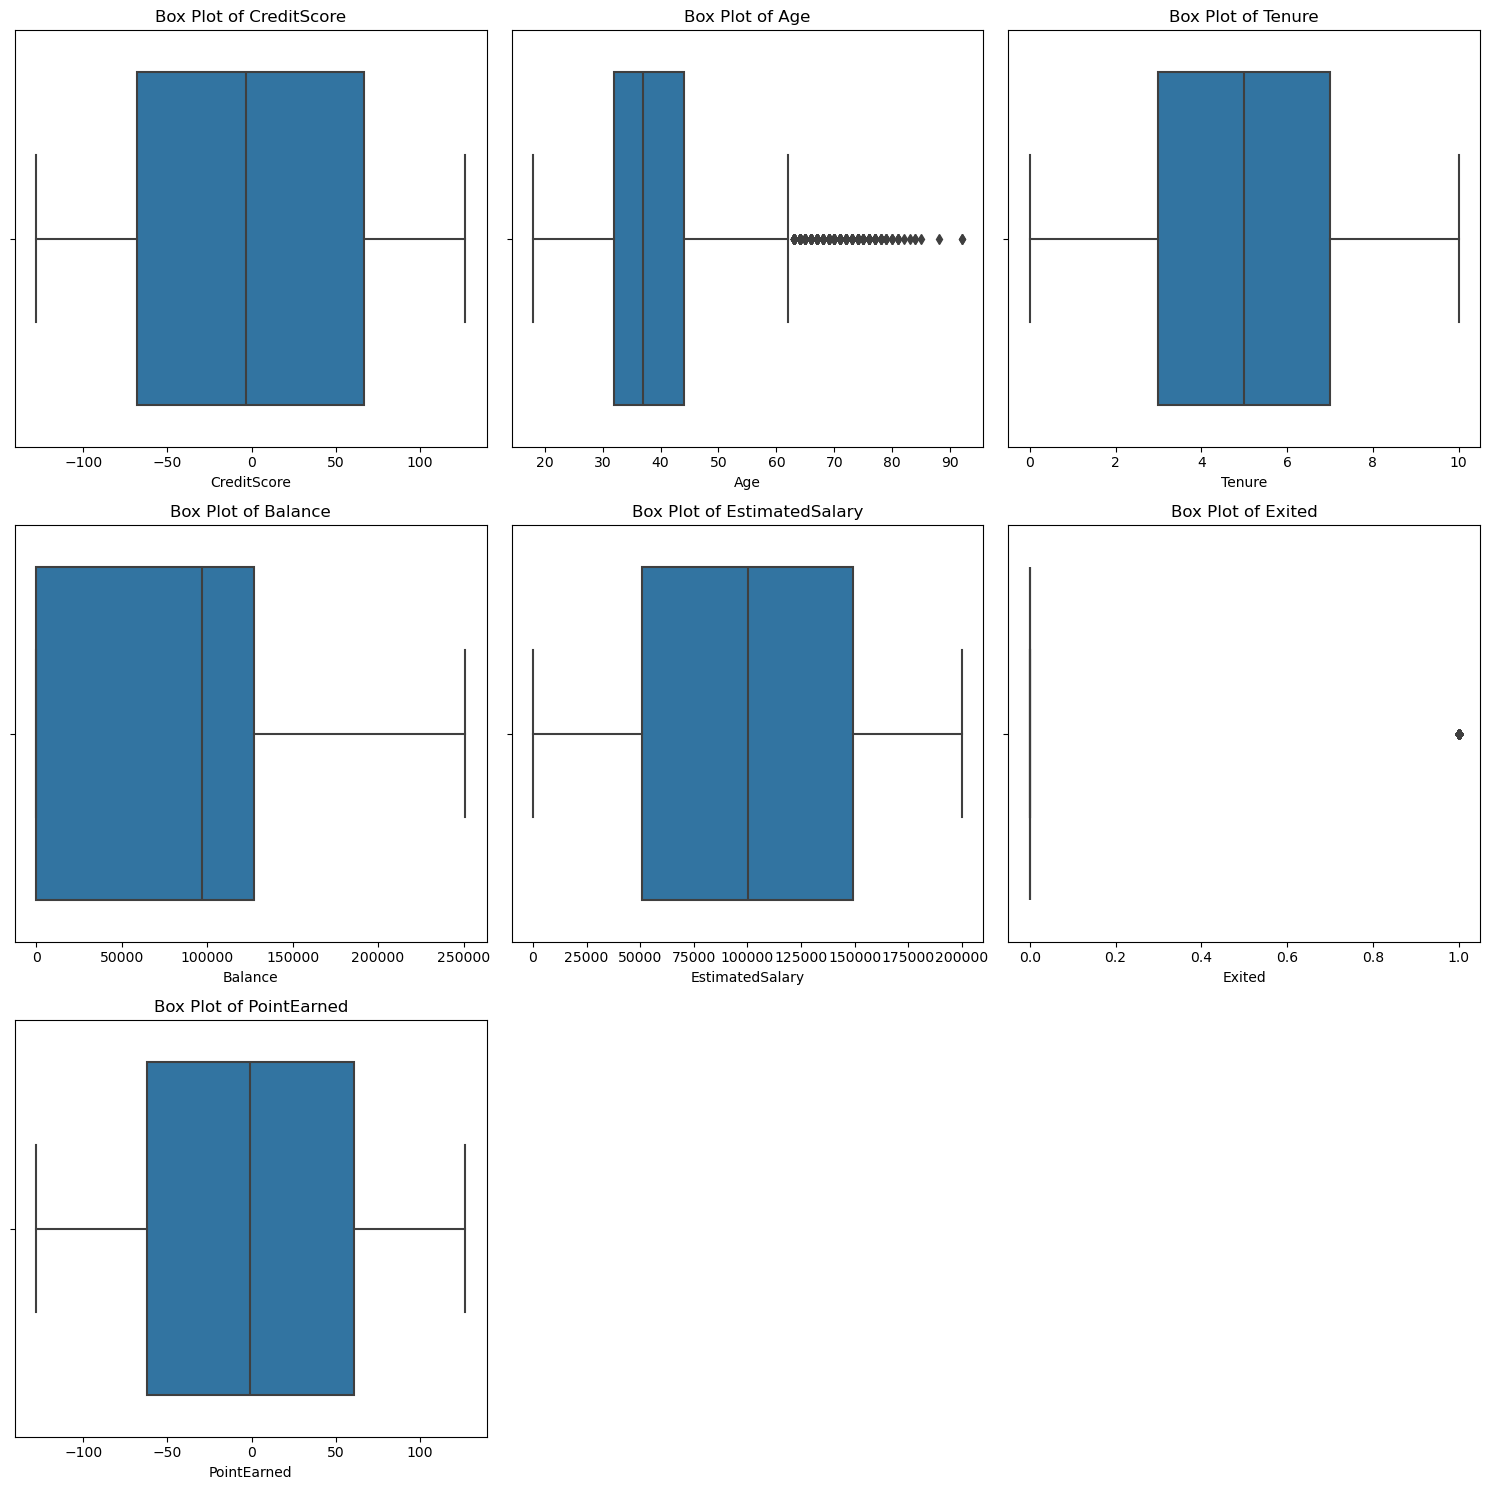

In [100]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

numerical_features = df.select_dtypes(include=['int8', 'float32']).columns

# Determine number of rows and cols for subplots
n_cols = 3   # number of plots per row
n_features = len(numerical_features)
n_rows = math.ceil(n_features / n_cols)

plt.figure(figsize=(15, 5 * n_rows))

for i, col in enumerate(numerical_features, 1):
    plt.subplot(n_rows, n_cols, i)
    sns.boxplot(x=df[col])
    plt.title(f'Box Plot of {col}')
    plt.tight_layout()

plt.show()


The outlier were found in datasets at features. So we can not remove.

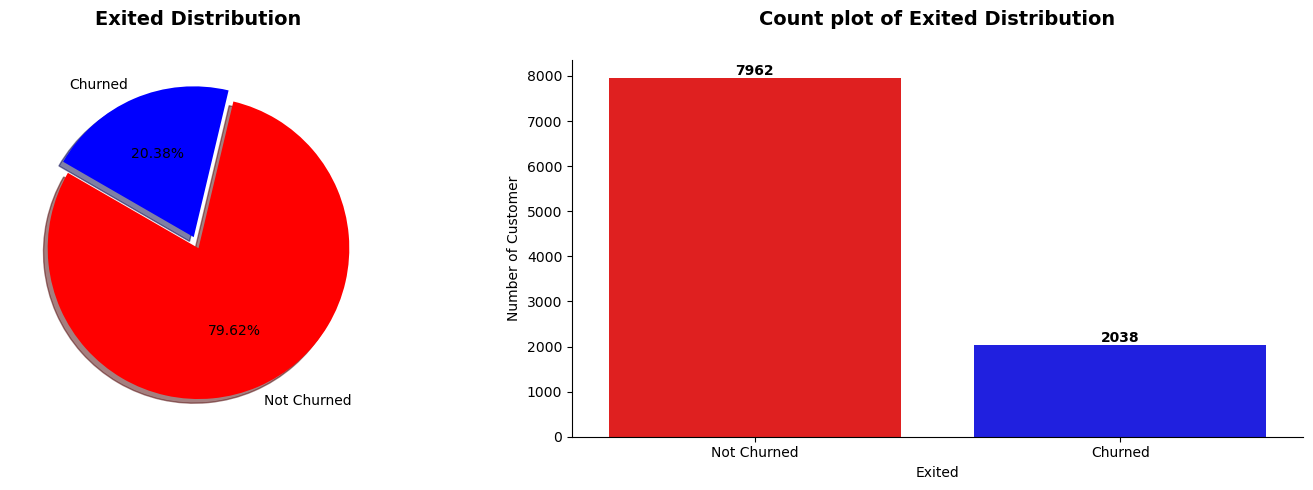

In [101]:
# use a simple color list instead of turtle.color
exited_Distribution  = df["Exited"].value_counts().loc[[0, 1]]
colors = ["red", "blue"]

fig, ax = plt.subplots(nrows=1, ncols=2, sharey=False, figsize=(15, 5))
# ax[0]
ax[0].pie(
    exited_Distribution,
    labels = ["Not Churned", "Churned"],
    colors = colors,
    autopct = "%1.2f%%",
    startangle = 150,
    explode = (0, 0.08),
    shadow= True
)
ax[0].set_title("Exited Distribution", weight="bold", fontsize=14, pad=25)

# ax[1]
sns.countplot(data=df, x = "Exited", palette=colors, ax=ax[1])
ax[1].set_title("Count plot of Exited Distribution", weight="bold", fontsize=14, pad=25)
for container in ax[1].containers:
    ax[1].bar_label(container, fmt="%d", label_type="edge", fontsize=10, weight="bold")
ax[1].set_ylabel("Number of Customer")
ax[1].set_xticks([0, 1])
ax[1].set_xticklabels(["Not Churned", "Churned"])
sns.despine(ax=ax[1], top=True, right=True, left=False, bottom=False)

plt.tight_layout()
plt.show()

/home/mrityunjay/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/mrityunjay/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/mrityunjay/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/mrityunjay/anaconda3/lib/python3.11/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future

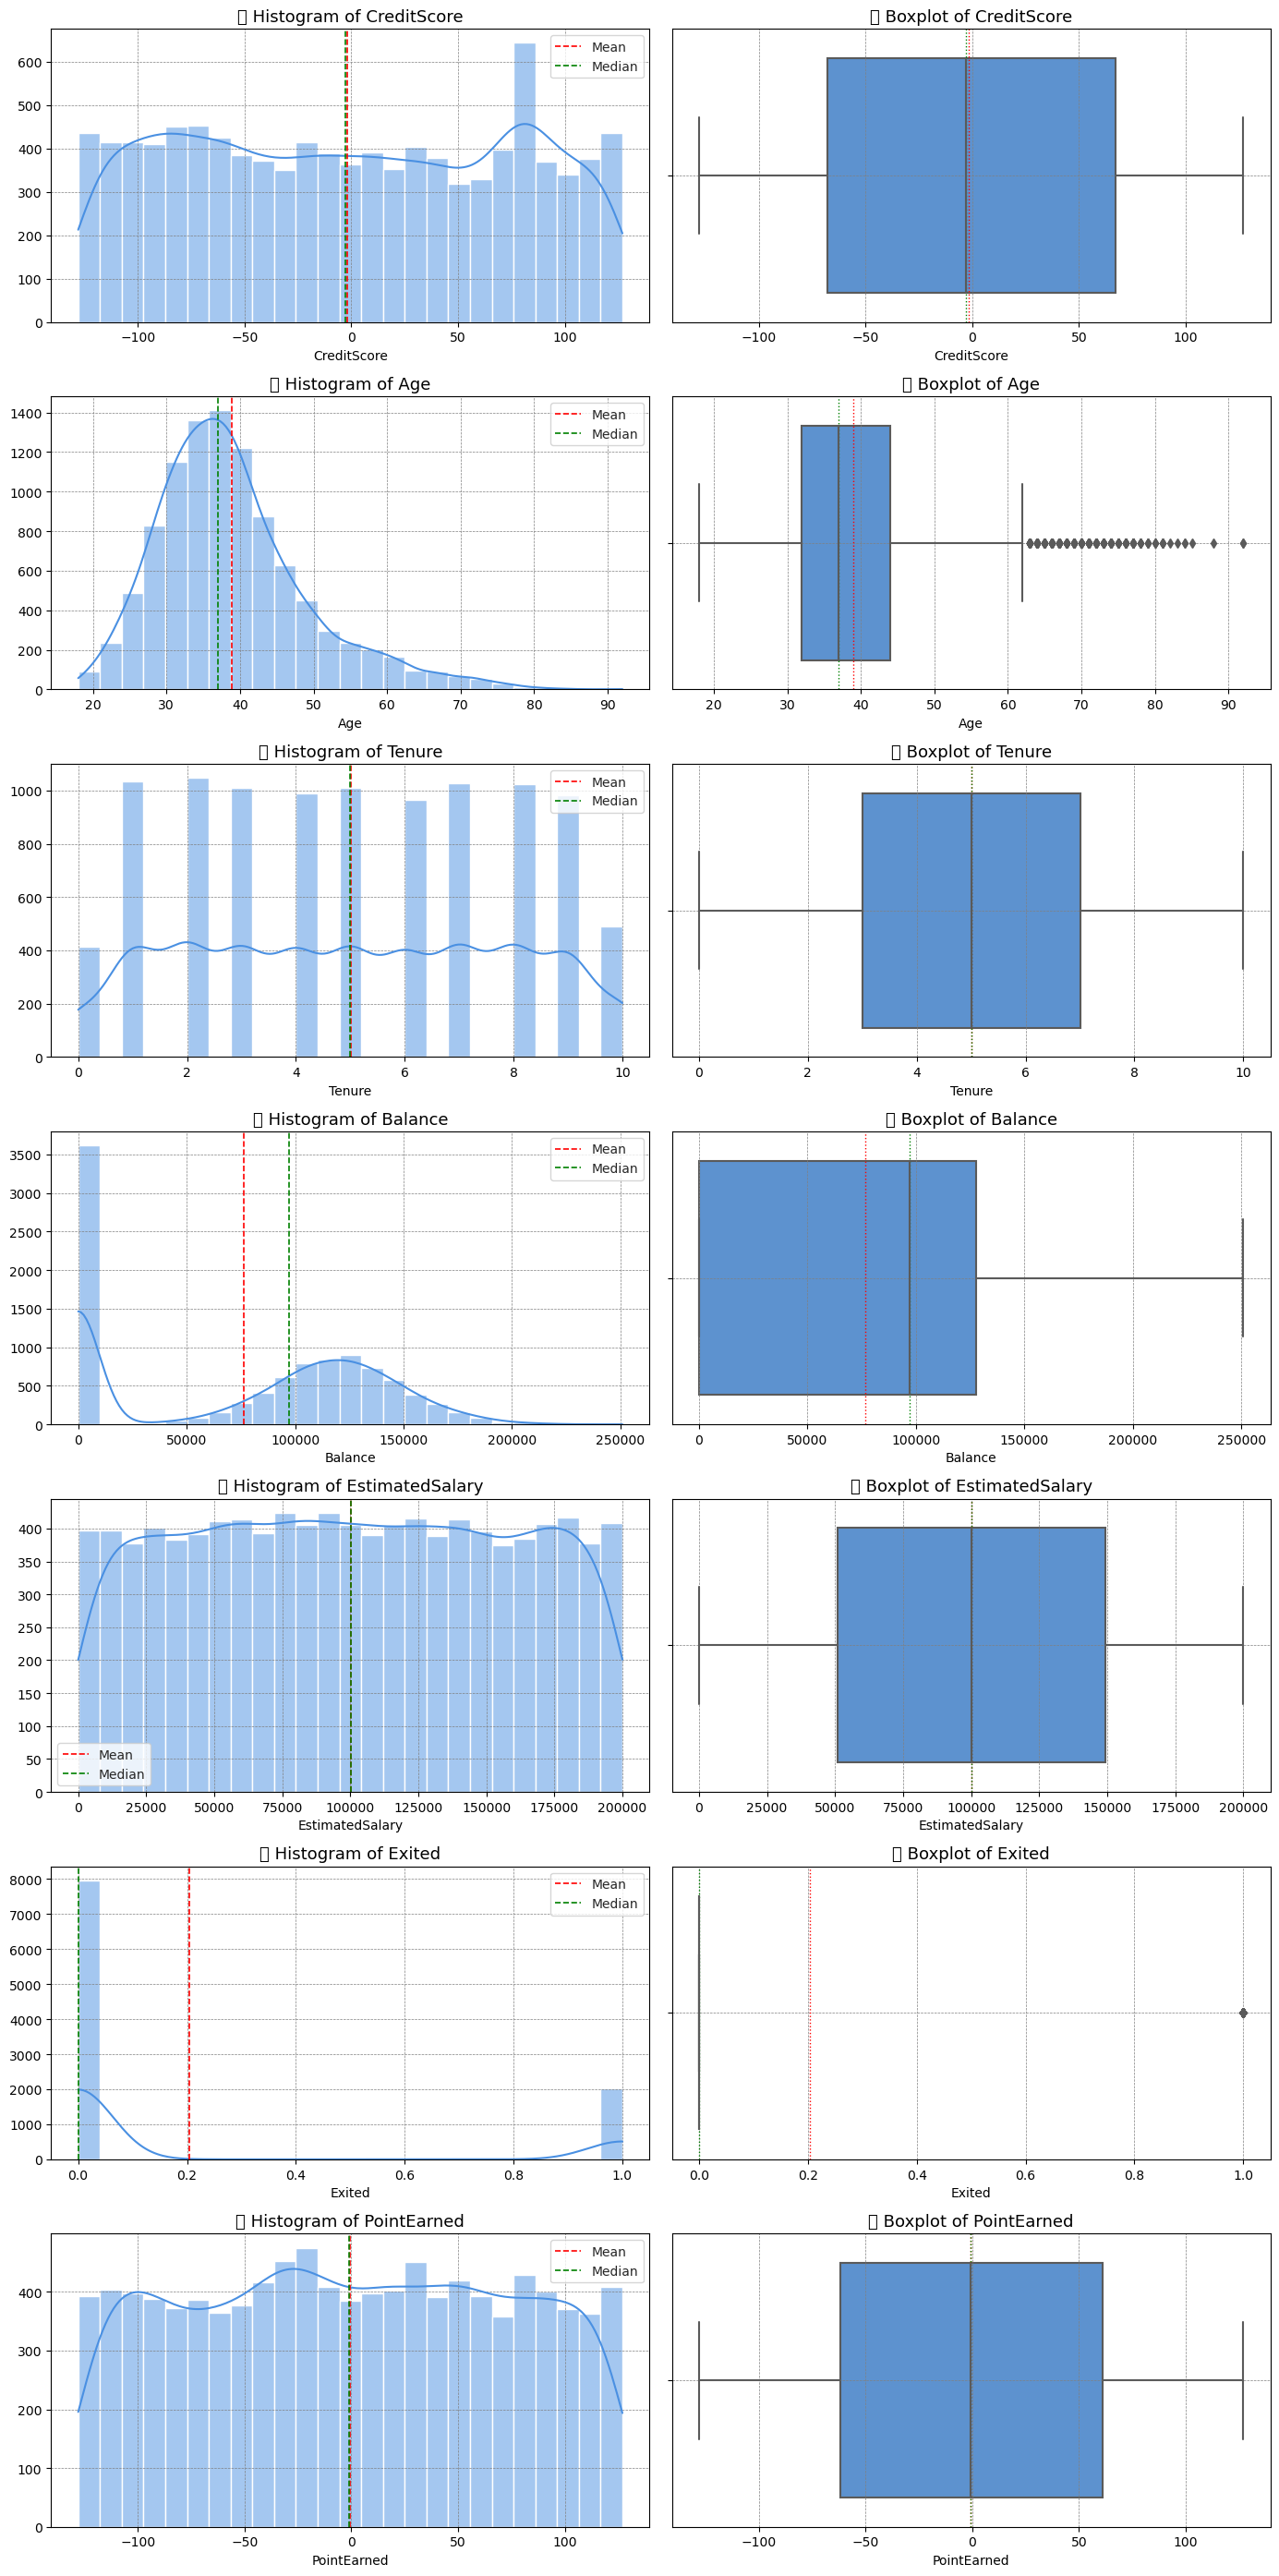

In [104]:
def plot_numerical_features(df, numerical_features=None):
    # Auto-detect numerical features if not provided
    if numerical_features is None:
        numerical_features = df.select_dtypes(include=['int', 'float']).columns.tolist()

    n_features = len(numerical_features)
    fig, axes = plt.subplots(n_features, 2, figsize=(14, n_features * 4))

    # ensure axes is always 2D for single-column case
    axes = np.atleast_2d(axes)

    sns.set_style("whitegrid")

    for i, feature in enumerate(numerical_features):
        col_data = df[feature].dropna()  # Remove missing values for cleaner plots

        # ---- Histogram + KDE ----
        sns.histplot(
            x=col_data, bins=25, kde=True, color="#4A90E2", ax=axes[i, 0]
        )
        axes[i, 0].set_title(f"📊 Histogram of {feature}", fontsize=13)
        axes[i, 0].set_ylabel("")
        axes[i, 0].grid(color="gray", linestyle="--", linewidth=0.5)

        # Add mean & median reference lines
        axes[i, 0].axvline(col_data.mean(), color="red", linestyle="--", linewidth=1.2, label="Mean")
        axes[i, 0].axvline(col_data.median(), color="green", linestyle="--", linewidth=1.2, label="Median")
        axes[i, 0].legend()

        # ---- Horizontal Boxplot ----
        sns.boxplot(
            x=col_data, color="#4A90E2", ax=axes[i, 1], orient="h"
        )
        axes[i, 1].set_title(f"📦 Boxplot of {feature}", fontsize=13)
        axes[i, 1].set_xlabel(feature)
        axes[i, 1].grid(color="gray", linestyle="--", linewidth=0.5)

        # Highlight mean & median in boxplot
        axes[i, 1].axvline(col_data.mean(), color="red", linestyle=":", linewidth=1)
        axes[i, 1].axvline(col_data.median(), color="green", linestyle=":", linewidth=1)

    plt.tight_layout()
    plt.show()

# Run the improved function
plot_numerical_features(df, numerical_features)
